# 第 11 章 · MDP 与价值迭代代码实验

[章节网页](../ch11.html)

## 运行内容

- 准备 Gridworld 转移表
- 执行价值迭代
- 绘制价值与策略

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# Gridworld：4x4 网格，左上和右下为终止状态，每走一步奖励 -1。
grid_size = 4
terminal_states = {"s00", "s33"}
states = [f"s{r}{c}" for r in range(grid_size) for c in range(grid_size)]
move_delta = {"上": (-1, 0), "下": (1, 0), "左": (0, -1), "右": (0, 1)}

actions = {}
transitions = {}
for r in range(grid_size):
    for c in range(grid_size):
        state = f"s{r}{c}"
        if state in terminal_states:
            actions[state] = []
            continue
        actions[state] = list(move_delta)
        for action, (dr, dc) in move_delta.items():
            nr = min(grid_size - 1, max(0, r + dr))
            nc = min(grid_size - 1, max(0, c + dc))
            next_state = f"s{nr}{nc}"
            transitions[(state, action)] = [(next_state, 1.0, -1.0)]

display(pd.DataFrame(
    [
        {"状态": s, "动作": a, "转移": transitions[(s, a)]}
        for s, acts in actions.items()
        for a in acts
    ]
).head(12))

,状态,动作,转移
0,s01,上,"[(s01, 1.0, -1.0)]"
1,s01,下,"[(s11, 1.0, -1.0)]"
2,s01,左,"[(s00, 1.0, -1.0)]"
3,s01,右,"[(s02, 1.0, -1.0)]"
4,s02,上,"[(s02, 1.0, -1.0)]"
5,s02,下,"[(s12, 1.0, -1.0)]"
6,s02,左,"[(s01, 1.0, -1.0)]"
7,s02,右,"[(s03, 1.0, -1.0)]"
8,s03,上,"[(s03, 1.0, -1.0)]"
9,s03,下,"[(s13, 1.0, -1.0)]"


## 1. 价值迭代

In [3]:
# 价值迭代：反复应用 Bellman 最优方程。
def value_iteration(states, actions, transitions, gamma=0.9, iterations=12):
    V = {state: 0.0 for state in states}
    rows = []
    policy_rows = []

    for it in range(1, iterations + 1):
        new_V = V.copy()
        for state in states:
            if not actions[state]:
                continue
            q_values = {}
            for action in actions[state]:
                q_values[action] = sum(
                    prob * (reward + gamma * V[next_state])
                    for next_state, prob, reward in transitions[(state, action)]
                )
            best_action = max(q_values, key=q_values.get)
            new_V[state] = q_values[best_action]
            if it == iterations:
                policy_rows.append({"状态": state, "最优动作": best_action, "Q值": round(q_values[best_action], 3)})
        V = new_V
        row = {"轮次": it}
        row.update({state: round(value, 3) for state, value in V.items()})
        rows.append(row)

    return pd.DataFrame(rows), pd.DataFrame(policy_rows)


value_trace, policy_df = value_iteration(states, actions, transitions)
display(value_trace.tail(6))
display(policy_df)

,轮次,s00,s01,s02,s03,s10,s11,s12,s13,s20,s21,s22,s23,s30,s31,s32,s33
6,7,0.0,-1.0,-1.9,-2.71,-1.0,-1.9,-2.71,-1.9,-1.9,-2.71,-1.9,-1.0,-2.71,-1.9,-1.0,0.0
7,8,0.0,-1.0,-1.9,-2.71,-1.0,-1.9,-2.71,-1.9,-1.9,-2.71,-1.9,-1.0,-2.71,-1.9,-1.0,0.0
8,9,0.0,-1.0,-1.9,-2.71,-1.0,-1.9,-2.71,-1.9,-1.9,-2.71,-1.9,-1.0,-2.71,-1.9,-1.0,0.0
9,10,0.0,-1.0,-1.9,-2.71,-1.0,-1.9,-2.71,-1.9,-1.9,-2.71,-1.9,-1.0,-2.71,-1.9,-1.0,0.0
10,11,0.0,-1.0,-1.9,-2.71,-1.0,-1.9,-2.71,-1.9,-1.9,-2.71,-1.9,-1.0,-2.71,-1.9,-1.0,0.0
11,12,0.0,-1.0,-1.9,-2.71,-1.0,-1.9,-2.71,-1.9,-1.9,-2.71,-1.9,-1.0,-2.71,-1.9,-1.0,0.0


,状态,最优动作,Q值
0,s01,左,-1.00
1,s02,左,-1.90
2,s03,下,-2.71
3,s10,上,-1.00
4,s11,上,-1.90
5,s12,上,-2.71
6,s13,下,-1.90
7,s20,上,-1.90
8,s21,上,-2.71
9,s22,下,-1.90


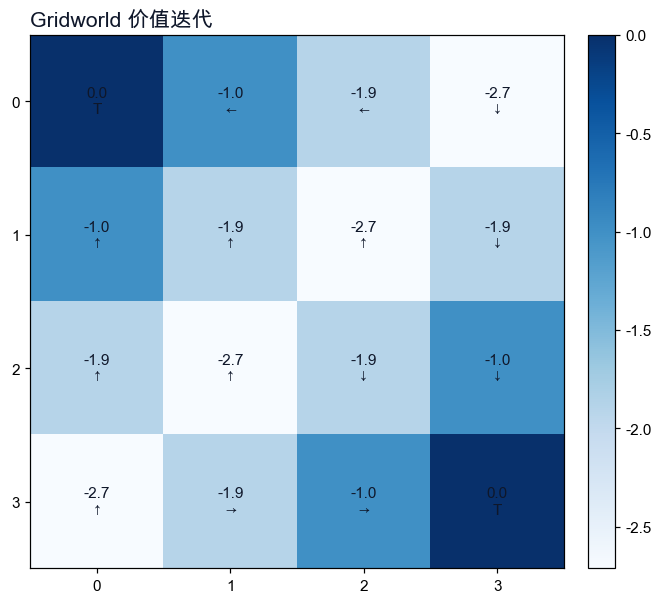

In [4]:
# 绘制 Gridworld 最终价值和最优动作。
final_values = value_trace.iloc[-1][states].to_dict()
value_grid = np.array([[final_values[f"s{r}{c}"] for c in range(grid_size)] for r in range(grid_size)])
policy_map = dict(zip(policy_df["状态"], policy_df["最优动作"]))
arrow = {"上": "↑", "下": "↓", "左": "←", "右": "→"}

fig, ax = plt.subplots(figsize=(6.2, 5.6))
im = ax.imshow(value_grid, cmap="Blues")
for r in range(grid_size):
    for c in range(grid_size):
        state = f"s{r}{c}"
        label = "T" if state in terminal_states else arrow[policy_map[state]]
        ax.text(c, r, f"{value_grid[r, c]:.1f}\n{label}", ha="center", va="center", color="#0f172a", fontweight="bold")
ax.set_title("Gridworld 价值迭代", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()